# 02) Modeling - Pitch Control

**SDC Master's Final Project - soccernet-setpiece-vision**

**CRISP-DM phase 4 (Modelling).** This is where positions become a tactical quantity. Given player coordinates for each set-piece frame - from the computer-vision pipeline on one side, and from ground-truth annotation on the other - we compute a Pitch Control surface for each, using one identical model. Running both through the same model is deliberate: it means any later difference between them reflects detection and calibration quality, not a difference in modelling.

Player positions arrive already prepared (the Data Preparation phase): detection, tracking, team assignment, and camera calibration are handled upstream in the pipeline, and the StatsBomb conversion in notebook 01. This notebook takes those positions as given and turns them into Pitch Control.

**The model.** Laurie Shaw's Friends-of-Tracking implementation of the Spearman (2018) time-to-intercept model. A point on the pitch belongs to whichever team can reach it first; aggregated over a grid, this yields a continuous control surface valued in [0, 1].

**Static-frame assumption and why it is fair.** SoccerNet GSR clips are sampled at the moment of execution, so player velocities are not available. We therefore assume **zero velocity** for every player, which turns Pitch Control into an *instantaneous* surface that ignores momentum. This is a genuine simplification, but it is applied identically to the pipeline and the ground truth, so it cannot bias the comparison between them — any distributional difference is driven by detection and homography quality, not by motion modelling.

**Attacking team.** Defined per frame as the team whose nearest player is closest to the ball.

**Output.** `outputs/pitch_control.parquet` - one row per (clip, frame, source) with summary metrics describing each control surface.

## 0. Setup and Imports

In [1]:
import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GSR_ROOT = Path(os.getenv("SOCCERNET_LOCAL_DIR", "data/soccernet-gsr")) / "gamestate-2024"
PITCH_LENGTH_M = 105.0
PITCH_WIDTH_M = 68.0

# Pitch control grid (cells across length / width)
GRID_NX = 60   # ~1.75 m per cell
GRID_NY = 40   # ~1.7  m per cell

# Laurie Shaw / Spearman model params (Friends of Tracking defaults)
MAX_SPEED = 5.0       # m/s
REACTION_TIME = 0.7   # s
SIGMA = 0.45          # logistic slope on TTI
LAMBDA = 4.3          # rate constant for ball-control
TIME_TO_INTERCEPT_SIGMOID_K = np.pi / (np.sqrt(3.0) * SIGMA)

print(f"Outputs: {OUTPUTS_DIR.relative_to(PROJECT_ROOT)}")

Outputs: outputs


## 1. Load Player Positions and Ball Locations

We load the prepared player positions for both sources (pipeline and ground truth) over the same set-piece clips and frames, together with the ball position at each frame. These positions are the only input the Pitch Control model needs.

In [2]:
# GT detections are committed. Pipeline (Soccana) detections are video-derived and may not be
# bundled in every checkout; when absent we fall back to the committed pipeline PC parquet.
gt_df = pd.read_parquet(OUTPUTS_DIR / "detections_gt_full.parquet")

PIPELINE_DET_PATH = OUTPUTS_DIR / "detections_soccana_tvcalib.parquet"
HAS_PIPELINE_DETECTIONS = PIPELINE_DET_PATH.is_file()
if HAS_PIPELINE_DETECTIONS:
    pipeline_df = pd.read_parquet(PIPELINE_DET_PATH)
    print("pipeline_df:", pipeline_df.shape, "(live recompute)")
else:
    pipeline_df = None
    print("pipeline_df: pipeline detections absent -> pipeline PC loaded from committed parquet")
print("gt_df      :", gt_df.shape)
gt_df.head()

pipeline_df: (21799, 17) (live recompute)
gt_df      : (18539, 9)


,split,clip_id,action_class,frame_idx,x_m,y_m,team,role,track_id
0,train,SNGS-066,Direct free-kick,1,1.678870,33.686141,left,goalkeeper,1
1,train,SNGS-066,Direct free-kick,1,15.009207,44.971701,right,player,2
2,train,SNGS-066,Direct free-kick,1,14.246440,44.314538,right,player,3
3,train,SNGS-066,Direct free-kick,1,22.852806,39.109550,right,player,4
4,train,SNGS-066,Direct free-kick,1,14.765675,42.382855,right,player,6


In [3]:
def parse_ball_position(clip_path: Path, frame_idx: int) -> tuple[float, float] | None:
    """Read SoccerNet GT ball annotation for a given frame, return metric pitch (x_m, y_m)."""
    label_path = clip_path / "Labels-GameState.json"
    if not label_path.is_file():
        return None
    labels = json.load(open(label_path))
    target = f"{frame_idx:06d}.jpg"
    image_id = next((img["image_id"] for img in labels["images"] if img.get("file_name") == target), None)
    if image_id is None:
        return None
    for a in labels["annotations"]:
        if a.get("image_id") != image_id or a.get("category_id") != 4:
            continue
        bp = a.get("bbox_pitch")
        if not bp:
            continue
        x_centred = bp.get("x_bottom_middle")
        y_centred = bp.get("y_bottom_middle")
        if x_centred is None or y_centred is None:
            continue
        return float(x_centred) + PITCH_LENGTH_M / 2, float(y_centred) + PITCH_WIDTH_M / 2
    return None


# Ball positions per (split, clip_id, frame_idx).
# Dataset path: read the GT ball annotation from the SoccerNet GSR label JSONs.
# Committed-parquet path: reuse the ball positions already stored in the committed PC parquets,
#                so the notebook runs end-to-end from public outputs alone.
if GSR_ROOT.is_dir():
    frame_keys = (
        pd.concat([gt_df[["split", "clip_id", "frame_idx"]]]
                  + ([pipeline_df[["split", "clip_id", "frame_idx"]]] if HAS_PIPELINE_DETECTIONS else []),
                  ignore_index=True)
        .drop_duplicates()
    )
    ball_rows = []
    for _, row in frame_keys.iterrows():
        cp = GSR_ROOT / row["split"] / row["clip_id"]
        bp = parse_ball_position(cp, int(row["frame_idx"]))
        ball_rows.append({
            "split": row["split"], "clip_id": row["clip_id"], "frame_idx": int(row["frame_idx"]),
            "ball_x_m": bp[0] if bp else np.nan, "ball_y_m": bp[1] if bp else np.nan,
        })
    balls_df = pd.DataFrame(ball_rows)
    print(f"Ball source: SoccerNet GT labels (GSR dataset)")
else:
    committed_pc = pd.concat([
        pd.read_parquet(OUTPUTS_DIR / "pitch_control_gt_full.parquet"),
        pd.read_parquet(OUTPUTS_DIR / "pitch_control_soccana_tvcalib.parquet"),
    ], ignore_index=True)
    balls_df = (
        committed_pc[["split", "clip_id", "frame_idx", "ball_x_m", "ball_y_m"]]
        .dropna(subset=["ball_x_m", "ball_y_m"])
        .drop_duplicates(subset=["split", "clip_id", "frame_idx"])
        .reset_index(drop=True)
    )
    print(f"Ball source: committed PC parquets (no raw video)")

print(f"frames: {len(balls_df)}  |  with ball: {balls_df['ball_x_m'].notna().sum()}")
balls_df.head()

Ball source: SoccerNet GT labels (GSR dataset)
frames: 1023  |  with ball: 949


,split,clip_id,frame_idx,ball_x_m,ball_y_m
0,train,SNGS-066,1,23.821790,9.184923
1,train,SNGS-066,2,23.821646,9.186275
2,train,SNGS-066,3,23.821409,9.189015
3,train,SNGS-066,4,23.821296,9.193514
4,train,SNGS-066,5,23.821590,9.200247


## 2. Pitch Control Model (vendored Laurie Shaw)

Time-to-intercept: each player accelerates to `MAX_SPEED` after `REACTION_TIME`, in a straight line to the target point.
Probability of reaching the point first follows a logistic on the team-min TTI difference.
Ball-control build-up uses an exponential rate `LAMBDA`.
Static-frame mode: initial velocity is zero for every player.

**Vendor reference (locked for reproducibility):**
- Source: `https://github.com/Friends-of-Tracking-Data-FoTD/LaurieOnTracking`
- Reference commit: `21f4c2d` (master, 2020-09-15) — base implementation of `Pitch_Control.py`.
- Adapted in-notebook (no external import) to remove tracking-data dependency: zero-velocity, single-frame input.
- Parameters fixed: `MAX_SPEED=5.0 m/s`, `REACTION_TIME=0.7 s`, `SIGMA=0.45 s`, sigmoid k=`pi/(sqrt(3)*SIGMA)`.
- Grid: `60 x 40` (1.75 m x 1.70 m cells on 105 x 68 m pitch).
- Any deviation from these constants invalidates the validation in nb04.


In [4]:
def time_to_intercept(player_xy: np.ndarray, target_xy: np.ndarray) -> np.ndarray:
    """Static-frame TTI: REACTION_TIME + straight-line distance / MAX_SPEED.

    player_xy: (N, 2) player positions in metres.
    target_xy: (M, 2) grid point positions in metres.
    Returns (N, M) TTI in seconds.
    """
    diff = player_xy[:, None, :] - target_xy[None, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return REACTION_TIME + dist / MAX_SPEED


def pitch_control_surface(att_xy: np.ndarray, def_xy: np.ndarray, ball_xy: tuple[float, float],
                          nx: int = GRID_NX, ny: int = GRID_NY) -> np.ndarray:
    """Compute attacking-team Pitch Control surface on a regular grid.

    Returns ny x nx array of attacking-control probabilities in [0, 1].
    Defending control = 1 - attacking control.
    """
    xs = np.linspace(0.0, PITCH_LENGTH_M, nx)
    ys = np.linspace(0.0, PITCH_WIDTH_M, ny)
    grid = np.array(np.meshgrid(xs, ys)).reshape(2, -1).T  # (nx*ny, 2)

    if len(att_xy) == 0 or len(def_xy) == 0:
        return np.full((ny, nx), 0.5)

    tti_att = time_to_intercept(att_xy, grid).min(axis=0)  # (M,)
    tti_def = time_to_intercept(def_xy, grid).min(axis=0)

    # Logistic on the TTI difference: P(att first) = 1 / (1 + exp(k*(tti_att - tti_def)))
    delta = tti_att - tti_def
    p_att = 1.0 / (1.0 + np.exp(TIME_TO_INTERCEPT_SIGMOID_K * delta))
    return p_att.reshape(ny, nx)

## 3. Compute Pitch Control per frame

We apply the model to every set-piece frame, for both sources. Each frame is split into attacking and defending teams by ball proximity, a control surface is computed, and the surface is reduced to five interpretable summary metrics (overall control, control at the ball, in the box, in the attacking third, and the share of the pitch controlled). These metrics are what the evaluation in notebook 03 compares.

In [5]:
def split_attack_defend(players_xy: np.ndarray, team_labels: np.ndarray, ball_xy: tuple[float, float]):
    """Pick attacking team = whichever of the two teams is closer to the ball.
    Returns (att_xy, def_xy, attacking_label).
    """
    bx, by = ball_xy
    teams = [t for t in np.unique(team_labels) if t is not None and t != -1 and not (isinstance(t, float) and np.isnan(t))]
    if len(teams) < 2:
        return players_xy, np.zeros((0, 2)), teams[0] if teams else None
    # min distance from ball per team
    min_d = {}
    for t in teams:
        mask = team_labels == t
        if mask.sum() == 0:
            continue
        d = np.linalg.norm(players_xy[mask] - np.array([bx, by]), axis=1)
        min_d[t] = d.min()
    att_team = min(min_d, key=min_d.get)
    def_team = [t for t in min_d if t != att_team][0]
    return players_xy[team_labels == att_team], players_xy[team_labels == def_team], att_team


def summarise_surface(pc: np.ndarray, ball_xy: tuple[float, float]) -> dict:
    """Distributional summary metrics of an attacking-team PC surface."""
    bx, by = ball_xy
    ny, nx = pc.shape
    xs = np.linspace(0.0, PITCH_LENGTH_M, nx)
    ys = np.linspace(0.0, PITCH_WIDTH_M, ny)
    # cell at ball
    ix = int(np.clip(round((bx / PITCH_LENGTH_M) * (nx - 1)), 0, nx - 1))
    iy = int(np.clip(round((by / PITCH_WIDTH_M) * (ny - 1)), 0, ny - 1))
    pc_at_ball = float(pc[iy, ix])
    # masks
    XX, YY = np.meshgrid(xs, ys)
    pen_left  = (XX <= 16.5) & (YY >= 13.84) & (YY <= 54.16)
    pen_right = (XX >= PITCH_LENGTH_M - 16.5) & (YY >= 13.84) & (YY <= 54.16)
    in_pen = pen_left | pen_right
    att_third_left  = XX <= PITCH_LENGTH_M / 3
    att_third_right = XX >= 2 * PITCH_LENGTH_M / 3
    # Choose the side closer to the ball as the relevant attacking third / box
    if bx < PITCH_LENGTH_M / 2:
        att_third = att_third_left
        att_box   = pen_left
    else:
        att_third = att_third_right
        att_box   = pen_right
    return {
        "pc_mean": float(pc.mean()),
        "pc_at_ball": pc_at_ball,
        "pc_in_box": float(pc[att_box].mean()) if att_box.any() else np.nan,
        "pc_in_third": float(pc[att_third].mean()) if att_third.any() else np.nan,
        "pc_area_gt_0p5": float((pc > 0.5).mean()),
    }


def process_track(df: pd.DataFrame, track_name: str, team_col: str, balls: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (split, clip_id, frame_idx), g in df.groupby(["split", "clip_id", "frame_idx"]):
        ball_row = balls[(balls["split"] == split) & (balls["clip_id"] == clip_id) & (balls["frame_idx"] == frame_idx)]
        if ball_row.empty or ball_row["ball_x_m"].isna().any():
            continue
        ball_xy = (float(ball_row["ball_x_m"].iloc[0]), float(ball_row["ball_y_m"].iloc[0]))
        players_xy = g[["x_m", "y_m"]].to_numpy()
        teams = g[team_col].to_numpy()
        att_xy, def_xy, att_label = split_attack_defend(players_xy, teams, ball_xy)
        if len(att_xy) == 0 or len(def_xy) == 0:
            continue
        pc = pitch_control_surface(att_xy, def_xy, ball_xy)
        m = summarise_surface(pc, ball_xy)
        action_class = g["action_class"].iloc[0] if "action_class" in g.columns else None
        out.append({
            "split": split, "clip_id": clip_id, "frame_idx": int(frame_idx),
            "track": track_name, "action_class": action_class,
            "n_attackers": int(len(att_xy)), "n_defenders": int(len(def_xy)),
            "ball_x_m": ball_xy[0], "ball_y_m": ball_xy[1],
            **m,
        })
    return pd.DataFrame(out)


# GT PC is recomputed live from committed GT detections (no raw video needed).
gt_pc = process_track(gt_df, track_name="gt", team_col="team", balls=balls_df)

# Pipeline PC needs the video-derived Soccana detections. When that parquet is present we
# recompute it live; otherwise we load the committed pipeline PC parquet so the notebook still runs.
if HAS_PIPELINE_DETECTIONS:
    pipe_pc = process_track(pipeline_df, track_name="pipeline", team_col="team_kmeans", balls=balls_df)
    print("pipeline PC frames:", len(pipe_pc), "(live recompute)")
else:
    pipe_pc = pd.read_parquet(OUTPUTS_DIR / "pitch_control_soccana_tvcalib.parquet")
    print("pipeline PC frames:", len(pipe_pc), "(committed parquet)")
print("GT       PC frames:", len(gt_pc))
gt_pc.head()

pipeline PC frames: 949 (live recompute)
GT       PC frames: 949


,split,clip_id,frame_idx,track,action_class,n_attackers,n_defenders,ball_x_m,ball_y_m,pc_mean,pc_at_ball,pc_in_box,pc_in_third,pc_area_gt_0p5
0,test,SNGS-116,1,gt,Corner,8,10,104.502290,0.871562,0.874105,1.0,0.415399,0.676894,0.902083
1,test,SNGS-116,2,gt,Corner,8,10,104.502725,0.871324,0.874082,1.0,0.415520,0.676842,0.901667
2,test,SNGS-116,3,gt,Corner,8,10,104.503573,0.870849,0.874034,1.0,0.415756,0.676735,0.902083
3,test,SNGS-116,4,gt,Corner,8,10,104.504795,0.870136,0.873959,1.0,0.416081,0.676566,0.902500
4,test,SNGS-116,5,gt,Corner,8,10,104.506331,0.869186,0.873860,1.0,0.416504,0.676339,0.902083


## 4. Sample Visualisation

A single representative frame, rendered as a Pitch Control heatmap for both sources side by side. This makes the abstract metrics tangible (red regions are attacker-controlled, blue defender-controlled) and gives a first visual read on how closely the pipeline's surface tracks the ground truth.

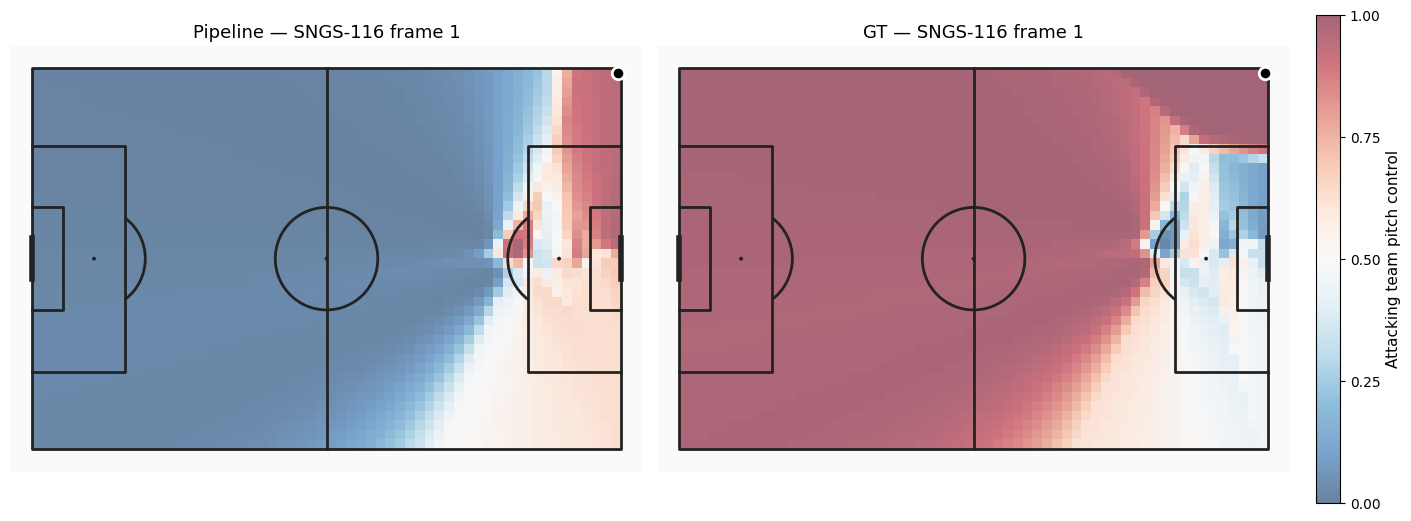

In [6]:
def plot_pc(ax, pc, ball_xy, title):
    pitch = Pitch(pitch_type="custom", pitch_length=PITCH_LENGTH_M, pitch_width=PITCH_WIDTH_M,
                  line_color="#222", pitch_color="#fafafa")
    pitch.draw(ax=ax)
    ax.invert_yaxis()  # SoccerNet y grows toward the main camera; invert so the minimap matches the broadcast view
    im = ax.imshow(pc, extent=(0, PITCH_LENGTH_M, PITCH_WIDTH_M, 0), origin="upper",
              cmap="RdBu_r", vmin=0, vmax=1, alpha=0.6)
    ax.set_aspect("equal")
    ax.scatter([ball_xy[0]], [ball_xy[1]], c="black", s=80, marker="o", edgecolor="white", linewidth=2)
    ax.set_title(title, fontsize=13)
    return im


def surface_from_detections(det_df, team_col, split, clip_id, frame_idx, ball_xy):
    """Recompute a single-frame PC surface from a detections table."""
    g = det_df[(det_df["split"] == split) & (det_df["clip_id"] == clip_id) & (det_df["frame_idx"] == frame_idx)]
    att, dfd, _ = split_attack_defend(g[["x_m", "y_m"]].to_numpy(), g[team_col].to_numpy(), ball_xy)
    return pitch_control_surface(att, dfd, ball_xy)


# Sample frame: first frame present in both PC tables.
# The GT panel is recomputed live from committed GT detections (always available).
# The pipeline panel is recomputed only when the Soccana detections parquet is present;
# without it the figure shows the GT surface alone (no raw video needed).
common = pd.merge(
    pipe_pc[["split", "clip_id", "frame_idx"]],
    gt_pc[["split", "clip_id", "frame_idx"]],
    on=["split", "clip_id", "frame_idx"],
)
if not common.empty:
    sample = common.iloc[0]
    s, c, f = sample["split"], sample["clip_id"], int(sample["frame_idx"])
    ball_xy = balls_df[(balls_df["split"] == s) & (balls_df["clip_id"] == c) & (balls_df["frame_idx"] == f)][["ball_x_m", "ball_y_m"]].iloc[0].tolist()

    pc_gt = surface_from_detections(gt_df, "team", s, c, f, ball_xy)
    panels = [(pc_gt, f"GT — {c} frame {f}")]
    if HAS_PIPELINE_DETECTIONS:
        pc_pipe = surface_from_detections(pipeline_df, "team_kmeans", s, c, f, ball_xy)
        panels.insert(0, (pc_pipe, f"Pipeline — {c} frame {f}"))
    else:
        print("Pipeline detections absent — showing GT sample surface only (no raw video needed).")

    fig, axes = plt.subplots(1, len(panels), figsize=(7.0 * len(panels), 5.1), constrained_layout=True, squeeze=False)
    axes = axes[0]
    im0 = None
    for ax, (pc, title) in zip(axes, panels):
        im0 = plot_pc(ax, pc, ball_xy, title)
    cbar = fig.colorbar(im0, ax=axes, orientation="vertical", fraction=0.025, pad=0.02)
    cbar.set_label("Attacking team pitch control", fontsize=11)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    fig.savefig(FIGURES_DIR / "07_pc_sample_pipeline_vs_gt.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5. Save Output

Persist the per-frame Pitch Control metrics for both sources to `pitch_control.parquet`, the single table the evaluation notebook draws on.

In [7]:
pc_all = pd.concat([pipe_pc, gt_pc], ignore_index=True)
out_path = OUTPUTS_DIR / "pitch_control.parquet"

if HAS_PIPELINE_DETECTIONS:
    pc_all.to_parquet(out_path, engine="pyarrow", index=False)
    size_kb = out_path.stat().st_size / 1024
    print(f"Saved (full run)    : {out_path.relative_to(PROJECT_ROOT)}  ({size_kb:.1f} KB)")
else:
    print("No raw video: committed pitch_control.parquet left untouched (full run required to regenerate).")

print(f"Rows total          : {len(pc_all)}")
print(f"  pipeline frames   : {len(pipe_pc)}")
print(f"  gt       frames   : {len(gt_pc)}")
pc_all.groupby("track")[["pc_mean", "pc_at_ball", "pc_in_box", "pc_in_third", "pc_area_gt_0p5"]].mean()

Saved (full run)    : outputs/pitch_control.parquet  (104.2 KB)
Rows total          : 1898
  pipeline frames   : 949
  gt       frames   : 949


,pc_mean,pc_at_ball,pc_in_box,pc_in_third,pc_area_gt_0p5
track,,,,,
gt,0.687234,0.97757,0.315904,0.513042,0.702572
pipeline,0.559708,0.94903,0.512178,0.530593,0.571698
